## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 1000)

## 2. Data Loading & Cleaning

In [2]:
df = pd.read_csv('data/clean/final_featuresv2.csv')

exclude_cols = [
    'state', 'date', 'inpatient_beds', 'inpatient_beds_used',
    'inpatient_beds_utilization', 'inpatient_beds_utilization_coverage', "hospital_inpatient_beds", "coverage_per_state",
]
columns_of_interest = [c for c in df.columns if c not in exclude_cols]

df = df[columns_of_interest].dropna().copy()
df

FileNotFoundError: [Errno 2] No such file or directory: 'data/clean/final_featuresv2.csv'

## 3. Random Forest — Predicting `hospital_inpatient_beds_used`

In [ ]:
SEED = 42

X = df.drop(columns='hospital_inpatient_beds_used')
y = df['hospital_inpatient_beds_used']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)


rfr = RandomForestRegressor(random_state=SEED)
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 3.1 Train vs Test R² (Overfitting Check)

In [ ]:
r2_train = r2_score(y_train, rfr.predict(X_train))
r2_test  = r2_score(y_test,  rfr.predict(X_test))

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")

Train R²: 0.9949
Test  R²: 0.9681
Gap:      0.0268  (>0.05 suggests overfitting)


### 3.2 Cross-Validated R²

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rfr, X, y, cv=tscv, scoring='r2')

print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

CV R² scores: [0.367  0.5586 0.4572 0.6044 0.7025]
Mean: 0.5379  |  Std: 0.1163


### 3.3 Feature Importances

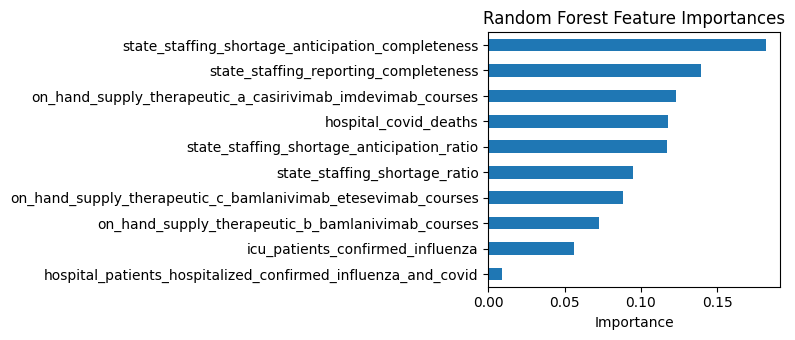

In [ ]:
importances = pd.Series(rfr.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()